# Deep Learning

# Tutorial 10: MNIST-Klassifikation mit Multi-Layer-Perzeptron (MLP)

In diesem Tutorial werden wir behandeln:

- Wie man ein einfaches neuronales Netz für die Bildklassifikation definiert und trainiert

Voraussetzungen:

- Python, Tensor-Grundlagen, Stochastischer Gradientenabstieg

Unsere Kontakte:

- Niklas Beuter (niklas.beuter@th-luebeck.de)
- Fenja Falta (fenja.falta@th-luebeck.de)

Kurs:

- Folien und Notebooks werden unter https://lernraum.th-luebeck.de/course/view.php?id=5383 verfügbar sein

### Importe

Zuerst importieren wir die notwendigen Module: `torch` für Tensoroperationen, `torch.nn` für neuronale Netzwerkmodule, `torch.nn.functional` für Aktivierungs- und Verlustfunktionen. `torchvision` stellt uns den MNIST-Datensatz zur Verfügung, und `tqdm.notebook` erstellt praktische Fortschrittsbalken während des Trainings.

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from tqdm.notebook import tqdm

### Laden und Vorverarbeiten des Datensatzes

Diese Zelle lädt den MNIST-Datensatz, wendet eine Transformation an, um Bilder in Tensoren umzuwandeln und zu normalisieren. Anschließend werden `DataLoader`-Objekte für den Trainings- und Validierungssatz erstellt.

In [7]:
# Define preprocessing transformations: Normalization
transform=torchvision.transforms.Compose([
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize((0.1307,), (0.3081,))
        ])
# Load the whole dataset (training & test)
dataset_train = torchvision.datasets.MNIST('./data', train=True, download=True,
                   transform=transform)
dataset_val = torchvision.datasets.MNIST('./data', train=False,
                    transform=transform)

# dataloader, which gives the data to the model
train_loader = torch.utils.data.DataLoader(dataset_train, batch_size=64)
val_loader = torch.utils.data.DataLoader(dataset_val, batch_size=1000)

## Datensatz-Visualisierung

Diese Zelle zeigt, wie man auf einzelne Bilder und deren Labels aus dem `dataset_train` zugreift und visualisiert die ersten fünf Bilder aus dem Trainingssatz. Unser Ziel ist es, ein neuronales Netzwerk zu trainieren, das das Label basierend auf einem Bild als Eingabe vorhersagt.

Shape of the Image: torch.Size([1, 28, 28]) (channels x height x width)
Label of the Image: 5


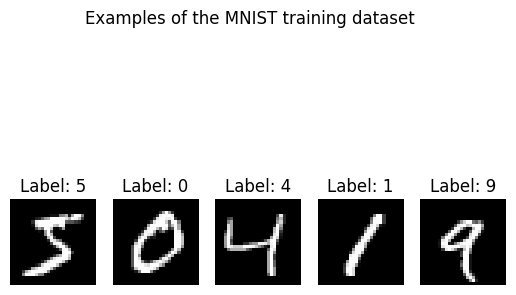

In [8]:
import matplotlib.pyplot as plt

# Access individual images an labels (here e.g. the first element)
image, label = dataset_train[0]
print(f"Shape of the Image: {image.shape}", "(channels x height x width)")
print(f"Label of the Image: {label}")

# visualize some examples
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(dataset_train[i][0][0, :, :], cmap='gray')
    plt.title(f"Label: {dataset_train[i][1]}")
    plt.axis('off')
plt.suptitle('Examples of the MNIST training dataset')
plt.show()

Lassen Sie uns einige Beispiele der Ziffer '5' aus dem Trainingsdatensatz anzeigen.

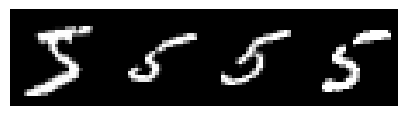

In [9]:
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1,4, figsize=(5, 20),gridspec_kw={'hspace': 0, 'wspace': 0})
idx_5 = [i for i, x in enumerate(dataset_train.targets) if x == 5]
for i, ax in enumerate(axs.flat):
  idx = idx_5[i]
  ax.imshow(dataset_train[idx][0][0,:,:], cmap='gray')
  ax.axis('off')

## MLP Modell-Definition (`MLPNet`)
Wir wollen eine Multi-Layer-Perzeptron (MLP)-Klasse namens `MLPNet` verwenden, die unsere Schichten in der `__init__`-Funktion und unseren Forward-Pass in der `forward`-Funktion definiert, welche die Eingabe an das Netzwerk (den Bildtensor) erhält und die Vorhersage (einen Wert für jede Klasse) ausgibt. Überprüfen Sie die PyTorch-Dokumentation, wenn Sie unsicher sind, wie die Funktionen zu verwenden sind.
> ## Übung
> 1. Definieren Sie zuerst Ihr neuronales Netzwerk. Es enthält zwei lineare Schichten (auch vollständig verbundene Schichten genannt), die mit `nn.Linear(in_channels, out_channels)` aufgerufen werden können. Die erste lineare Schicht bildet von der Anzahl der Pixel (*wie viele?*) auf die versteckte Dimension ab, die wir auf `128` setzen wollen. Die zweite lineare Schicht bildet von der versteckten Dimension auf die Anzahl der möglichen Klassen (*wie viele?*) ab.
> 2. Nachdem Sie die Schichten definiert haben, definieren Sie die `forward`-Funktion. Zuerst sollte sie das Eingabebild abflachen (verwenden Sie `torch.flatten` und stellen Sie sicher, dass Sie die Batch-Dimension nicht abflachen) und dann die beiden linearen Schichten anwenden. Nach der ersten linearen Schicht wenden Sie eine ReLU-Aktivierung (`F.relu`) an. Die letzte Schicht benötigt keine Aktivierungsfunktion.

In [11]:
class MLPNet(nn.Module):
    def __init__(self):
        super(MLPNet, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        return x

## Modell-Auswahl und Trainings-Schleife

Das Netzwerk-Training erfolgt in Epochen, wobei 1 Epoche bedeutet, alle Batches des Trainingsdatensatzes zu durchlaufen. Die allgemeine Struktur sieht wie folgt aus:
```
for epoch in range(1, 15):
    epoch_train_loss = train(model, train_loader, optimizer, epoch)
    epoch_val_loss = validate(model, val_loader)
```
Nun müssen wir `train` und `validate` definieren, um unser Modell für eine Epoche zu trainieren bzw. auf den Validierungsdaten zu validieren.

Um das Netzwerk zu trainieren, müssen wir das Modell zuerst in den Trainingsmodus versetzen, indem wir `model.train()` aufrufen. Dann iterieren wir über alle Batches, um unsere Parameter zu aktualisieren.
Das Training selbst besteht aus den folgenden Schritten:
- Verschieben Sie die Daten mit `.cuda()` auf die GPU.
- Setzen Sie den im Optimizer gespeicherten Gradienten mit `optimizer.zero_grad()` auf Null. Dies ist notwendig, um nur auf dem aktuellen Verlust zu optimieren, da wir sonst unseren aktuellen Gradienten zum letzten hinzufügen würden.
- Rufen Sie den Forward-Pass des Modells mit `model(data)` auf. Die Ausgabe ist Ihre aktuelle Vorhersage. Wenn `model.train()` aktiv ist, wird der Gradient gleichzeitig gespeichert.
- Berechnen Sie den Verlust. Da wir ein Klassifikationsproblem haben, wollen wir einen Cross-Entropy-Loss (`F.cross_entropy`) verwenden.
- Führen Sie den Backward-Pass aus, indem Sie `.backward()` auf den Verlust aufrufen. Dies berechnet die Gradienten und speichert sie intern.
- Aktualisieren Sie die Parameter, indem Sie `.step()` auf dem Optimizer aufrufen.

> ## Übung
> Vervollständigen Sie die `train`-Funktion basierend auf der obigen Beschreibung.

In [ ]:
def train(model, train_loader, optimizer, epoch):
    # TODO: Set model to training mode
    total_loss = 0
    for batch_idx, (data, target) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch} Training")):
        data, target = # TODO: Move data and target to GPU
        # TODO: Zero the gradients before running the backward pass
        output = # TODO: Perform a forward pass
        loss = # TODO: Calculate Cross-Entropy Loss
        # TODO: Perform a backward pass to compute gradients
        # TODO: Update model parameters
        total_loss += loss.item() # Accumulate the loss

    avg_epoch_loss = total_loss / len(train_loader)
    print(f'Train Epoch: {epoch} - Average Loss: {avg_epoch_loss:.6f}')
    return avg_epoch_loss

Für die Validierung können wir das Modell in den Evaluationsmodus versetzen, indem wir `model.eval()` aufrufen. Da wir keine Backpropagation auf unseren Validierungsdaten durchführen, müssen wir die Gradienten nicht speichern, sodass wir in einer `torch.no_grad()`-Umgebung arbeiten können. Wir müssen dann nur den Forward-Pass durchführen und den Verlust auf dem Validierungsdatensatz berechnen. Da die Validierung nicht differenzierbar sein muss, können wir auch die exakte Vorhersage erhalten, die das Ergebnis der `argmax`-Funktion ist, anstatt die differenzierbare `softmax` zu verwenden, die implizit von unserem Cross-Entropy-Verlust behandelt wird.
> ## Übung
> Vervollständigen Sie die `validate`-Funktion.

In [ ]:
def validate(model, val_loader):
    #TODO: Set model to evaluation mode.
    val_loss = 0
    correct = 0
    with torch.no_grad(): # Disable gradient calculation for validation
        for data, target in tqdm(val_loader, desc=f"Epoch {epoch} Validation"):
            data, target = # TODO: Move data and target to GPU
            output = # TODO: Perform a forward pass
            curr_val_loss = # TODO: Calculate Cross-Entropy Loss
            pred = output.argmax(dim=1, keepdim=True) # Get the index of the max log-probability as prediction
            correct += pred.eq(target.view_as(pred)).sum().item() # Count correct predictions
            val_loss += curr_val_loss.item()

    val_loss /= len(val_loader) # Calculate average validation loss

    print('\nTest set: Average loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
        val_loss, correct, len(val_loader.dataset),
        100. * correct / len(val_loader.dataset))) # Print validation metrics
    return val_loss

Jetzt können wir unsere Trainings- und Validierungsfunktionen ausführen. Wir müssen alle Parameter unseres Modells optimieren, die in der `__init__` initialisiert wurden. Diese können aufgerufen werden mit
> ## Übung
> Initialisieren Sie das Modell (und verschieben Sie es auf CUDA) und wählen Sie Adam als Ihren Optimierer. Sie sollten eine Genauigkeit von etwa 97-98% erreichen.

In [ ]:
model = # TODO: initialize the model and push it to cuda

optimizer = # TODO: Use Adam optimizer

train_losses = []
val_losses = []

for epoch in range(1, 15):
    epoch_train_loss = train(model, train_loader, optimizer, epoch)
    epoch_val_loss = validate(model, val_loader)
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)

> ## Übung
> Nach dem Training können wir die Verlustkurven visualisieren. Was sehen Sie, wenn Sie den Verlust des Trainings- und Validierungsdatensatzes vergleichen? Was glauben Sie, passiert hier?

In [ ]:
# Plot loss values over time using matplotlib
import matplotlib.pyplot as plt

plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()